In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(data.table)
    library(stringr)
    library(dplyr)
    library(parallel)
    library(glue)
    library(patchwork)
    library(ape)
    library(igraph)
    library(ggtree)
    library(ggpubr)
    library(tidygraph)
    library(ggrepel)
    library(ggtreeExtra)
    library(redeemR)
    library(Seurat)
    library(Signac)
    library(mitodrift)
})
filter = dplyr::filter
options(repr.matrix.max.cols=15, repr.matrix.max.rows=80)
rename = dplyr::rename
R.utils::sourceDirectory(glue('../../R'))

Warning message:
“package ‘data.table’ was built under R version 4.4.3”
Warning message:
“package ‘ggpubr’ was built under R version 4.4.3”
Warning message:
“replacing previous import ‘data.table::first’ by ‘dplyr::first’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘ape::where’ by ‘dplyr::where’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘data.table::last’ by ‘dplyr::last’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘data.table::between’ by ‘dplyr::between’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘data.table::melt’ by ‘reshape2::melt’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘data.table::dcast’ by ‘reshape2::dcast’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘ape::keep.tip’ by ‘tidytree::keep.tip’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘ape::drop.tip’ by ‘tidytree::drop.tip’ when loading ‘redeemR’”
Warning m

# Prepare data

In [4]:
donor = 'pL1000'

barcode_annot = fread(glue('../../../plarry/{donor}_barcode_annot_final.csv')) %>%
    mutate(component = as.character(component), annot = component)

In [5]:
seu = readRDS(glue('../../../plarry/seurat/pLarry_seurat_pL1000.rds'))

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


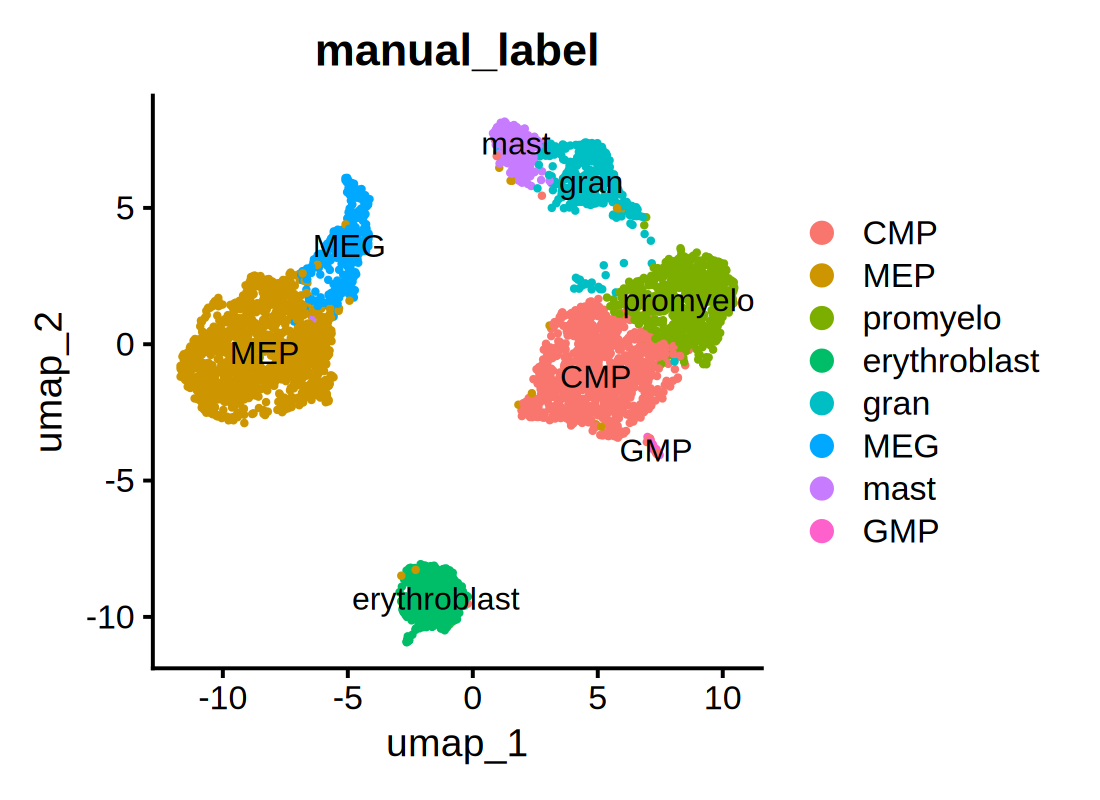

In [4]:
options(repr.plot.width = 5.5, repr.plot.height = 4, repr.plot.res = 200)

DimPlot(seu, label = TRUE, group.by = 'manual_label')

In [7]:
phy_annot = read.tree('../../../plarry/results/final/pL1000_full/tree_annotated.newick')
mut_dat = fread(glue('../../../plarry/mut_dat/final/pL1000_full_mut_dat.csv'))

Registered S3 method overwritten by 'TreeTools':
  method   from    
  [.phyDat phangorn



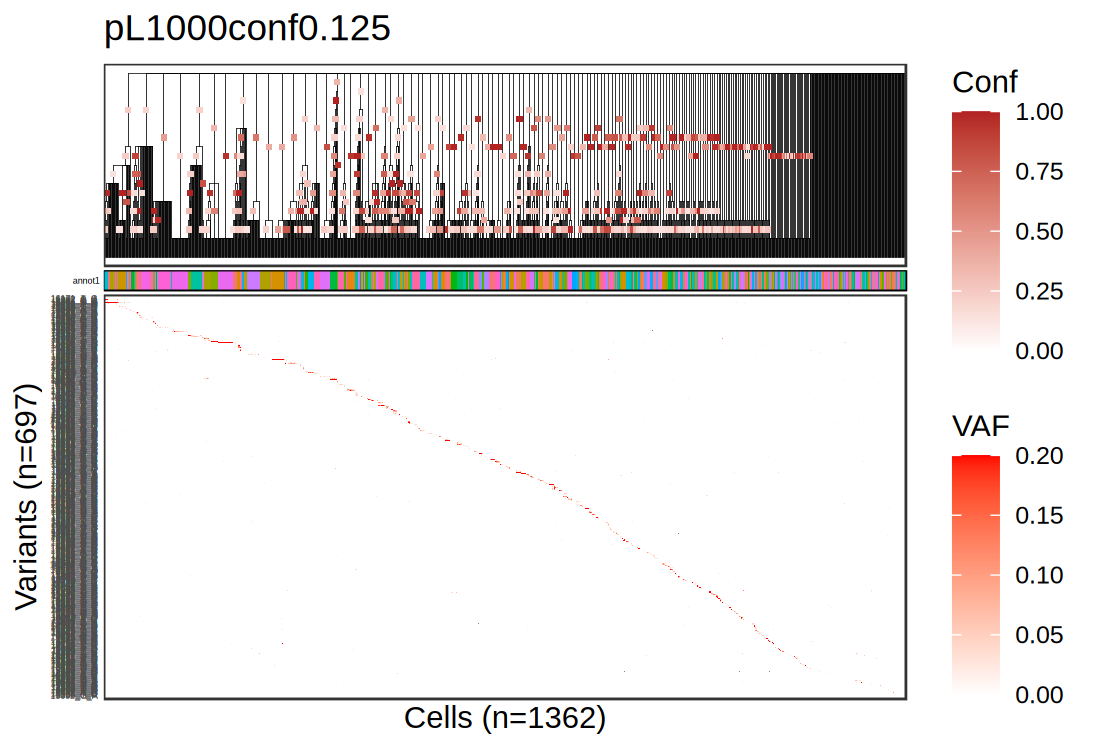

In [8]:
options(repr.plot.width = 5.5, repr.plot.height = 3.75, repr.plot.res = 200)

p_conf = 0.125
phy_trim = phy_annot %>% trim_tree(conf = p_conf)
clade_annot = assign_clones_polytomy(phy_trim)

plot_phylo_heatmap2(
    phy_trim,
    mut_dat,
    branch_length = F,
    branch_width = 0.1,
    het_max = 0.2,
    annot_legend = F,
    node_conf = T,
    conf_max = 1,
    conf_min = 0,
    cell_annot = barcode_annot,
    title = paste0(donor, 'conf', p_conf)
) %>% suppressMessages() %>%
suppressWarnings()

# Heritabilty per cell type

In [2]:
donor = 'pL1000'

barcode_annot = fread(glue('../../../plarry/{donor}_barcode_annot_final.csv')) %>%
    mutate(component = as.character(component), annot = component)

phy_tru_full = build_clone_tree(barcode_annot %>% {setNames(.$component, .$cell)})

In [9]:
# outdir_trees = '../../../plarry/phylosignal/final/trees'
# cts = c('MEP', 'CMP', 'MEG', 'promyelo')
# for (ct in cts) {
#     cells_select = seu@meta.data %>% filter(manual_label == ct) %>% rownames(.)
#     phy_trim %>% keep_tip_safe(cells_select) %>%
#         write.tree(file.path(outdir_trees, glue::glue("pL1000_{ct}_phy_trim.newick")))
#     phy_annot %>% keep_tip_safe(cells_select) %>%
#         write.tree(file.path(outdir_trees, glue::glue("pL1000_{ct}_phy_nj.newick")))
#     phy_tru_full %>% keep_tip_safe(cells_select) %>%
#         write.tree(file.path(outdir_trees, glue::glue("pL1000_{ct}_phy_tru.newick")))
# }

In [10]:
test_res_all = lapply(
    c('MEP', 'CMP', 'MEG', 'promyelo'),
    function(ct) {
        bind_rows(
            fread(glue('../../../plarry/phylosignal/final/pL1000_{ct}_phy_trim_tf_cmeans.csv')) %>%
                mutate(method = 'MitoDrift'),
            fread(glue('../../../plarry/phylosignal/final/pL1000_{ct}_phy_nj_tf_cmeans.csv')) %>%
                mutate(method = 'NJ'),
            fread(glue('../../../plarry/phylosignal/final/pL1000_{ct}_phy_tru_tf_cmeans.csv')) %>%
                mutate(method = 'barcode')
            # fread(glue('../../../plarry/phylosignal/pL1000_{ct}_phy_merlin_tf_cmeans.csv')) %>%
            #     mutate(method = 'MERLIN')
        ) %>%
        mutate(ct = ct)
}) %>%
bind_rows()

tf_mat = fread('../../../plarry/phylosignal/final/tf_auc_mat.csv') %>% tibble::column_to_rownames('V1') %>% as.matrix

df_exp_ct = data.frame(tf_mat, check.names = F) %>%
    tibble::rownames_to_column('gene') %>%
    reshape2::melt(id.var = c('gene'), variable.name = 'cell', value.name = 'score') %>%
    left_join(
        seu@meta.data %>% mutate(cell = rownames(.), ct = manual_label) %>% select(cell, ct),
        by = 'cell'
    ) %>%
    group_by(ct, gene) %>%
    summarise(
        exp_mean = mean(score), 
        exp_sd = sd(score), 
        cv = exp_sd/exp_mean,
        .groups = 'drop'
    )

myeloid_tfs <- c(
	"CEBPA", "CEBPB", "IRF8", 
	"RARB", "NR3C1", "MAF"
)

erythro_meg_tfs <- c(
	"GATA2", "GATA1", "KLF1", "KLF3",
	"MYB", "MEIS1", "GFI1B", "FLI1", "NFE2", "RREB1"
)

ap1_tfs = c("JUND", "FOSB")

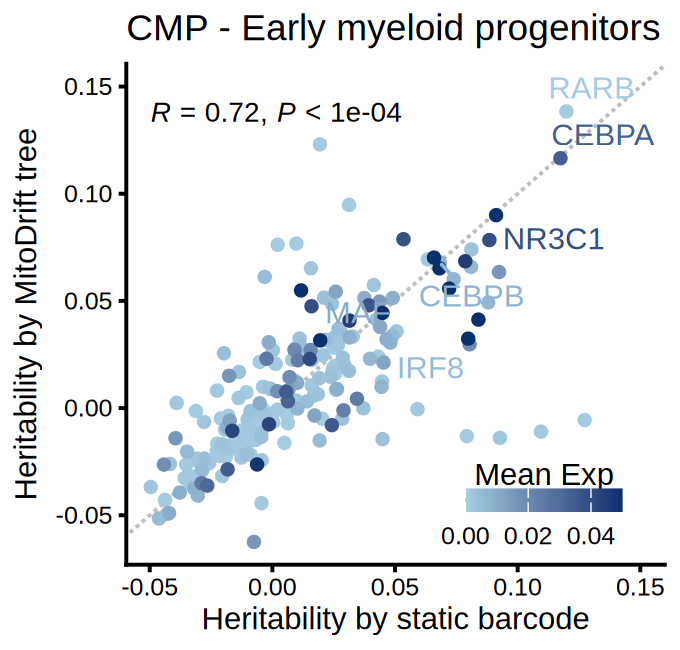

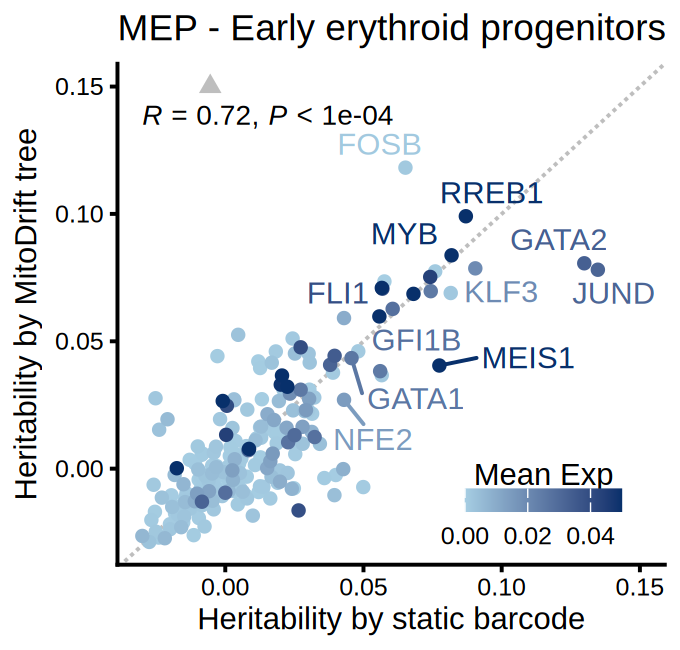

In [18]:
options(repr.plot.width = 3.4, repr.plot.height = 3.25, repr.plot.res = 200)

D = test_res_all %>% 
    dcast(gene + ct ~ method, value.var = 'cmean') %>%
    left_join(df_exp_ct, by = c('gene', 'ct')) %>%
    mutate(
        category = case_when(
            gene %in% myeloid_tfs ~ "myeloid TF",
            gene %in% erythro_meg_tfs ~ "erythro-meg TF",
            TRUE ~ "generic/other")
    ) %>%
    arrange(exp_mean)

maxlim = 0.15

# Cell type metadata
ct_info <- list(
    CMP = list(
        label_genes = myeloid_tfs,
        title = "CMP - Early myeloid progenitors"
    ),
    MEP = list(
        label_genes = c(erythro_meg_tfs, ap1_tfs),
        title = "MEP - Early erythroid progenitors"
    )
)

# Iterate through cell types
for (ct_name in c('CMP', 'MEP')) {
    # Capture values before pipeline to avoid scoping issues
    label_genes <- ct_info[[ct_name]]$label_genes
    plot_title <- ct_info[[ct_name]]$title
    
    # Filter to cell type and add out-of-bounds detection
    D_ct <- D %>% 
        filter(ct == ct_name) %>%
        mutate(
            out_of_bounds = (barcode > maxlim | MitoDrift > maxlim),
            barcode_clipped = pmin(barcode, maxlim),
            MitoDrift_clipped = pmin(MitoDrift, maxlim)
        )
    
    # Precompute correlation on original data (before clipping)
    cor_test <- cor.test(D_ct$barcode, D_ct$MitoDrift, method = "pearson")
    cor_r <- cor_test$estimate
    cor_p <- cor_test$p.value
    
    # Format p-value like ggpubr: show "p < threshold" for very small p-values
    p_threshold <- 1e-4
    if (cor_p < p_threshold) {
        p_label <- sprintf("italic(P)~'<'~%.0e", p_threshold)
    } else {
        p_label <- sprintf("italic(P)~'='~%.2e", cor_p)
    }
    
    # Format label in ggpubr style with italic R and p
    cor_label <- sprintf("italic(R)~'='~%.2f*','~%s", cor_r, p_label)

    xmin <- min(D_ct$barcode)
    
    p <- D_ct %>%
        mutate(label = ifelse(gene %in% label_genes, gene, '')) %>%
        ggplot(
            aes(x = barcode_clipped, y = MitoDrift_clipped, color = exp_mean, group = 1)
        ) +
        geom_abline(color = 'gray', linetype = 'dashed') +
        geom_point(data = . %>% filter(!out_of_bounds), aes(x = barcode, y = MitoDrift)) +
        geom_point(data = . %>% filter(out_of_bounds), color = "gray", shape = 17, size = 2.5, show.legend = FALSE) +
        geom_text_repel(aes(label = label), max.overlaps = Inf, seed = 0) +
        annotate("text", x = xmin, y = maxlim * 0.95, label = cor_label, 
                 hjust = 0, vjust = 1, size = 3.5, parse = TRUE) +
        theme_classic() +
        theme(
            # aspect.ratio = 1, 
            legend.position = c(0.95, 0),
            legend.justification = c(1, 0),
            legend.direction = 'horizontal',
            legend.title.position = 'top',
            legend.background = element_rect(fill = 'transparent', colour = NA),
            legend.key.height = unit(3, 'mm'),
            legend.key.width = unit(4, 'mm'),
            legend.title = element_text(hjust = 0.5, size = 11, margin = margin(0,0,0,0))
        ) +
        coord_cartesian(ylim = c(NA, maxlim), xlim = c(NA, maxlim)) +
        scale_shape_manual(values = c(0, 1, 2)) +
        scale_color_gradient(
            low = '#a6cee3', high = '#08306b', limits = c(0, 0.05),
            breaks = scales::pretty_breaks(n = 3),
            oob = scales::oob_squish,
            name = 'Mean Exp'
        ) +
        xlab('Heritability by static barcode') +
        ylab('Heritability by MitoDrift tree') +
        ggtitle(plot_title) +
        theme_transparent
    
    print(p)
    ggsave(glue('outputs/{ct_name}_heritability_scatter.pdf'), p, width = 3.4, height = 3.25)
}

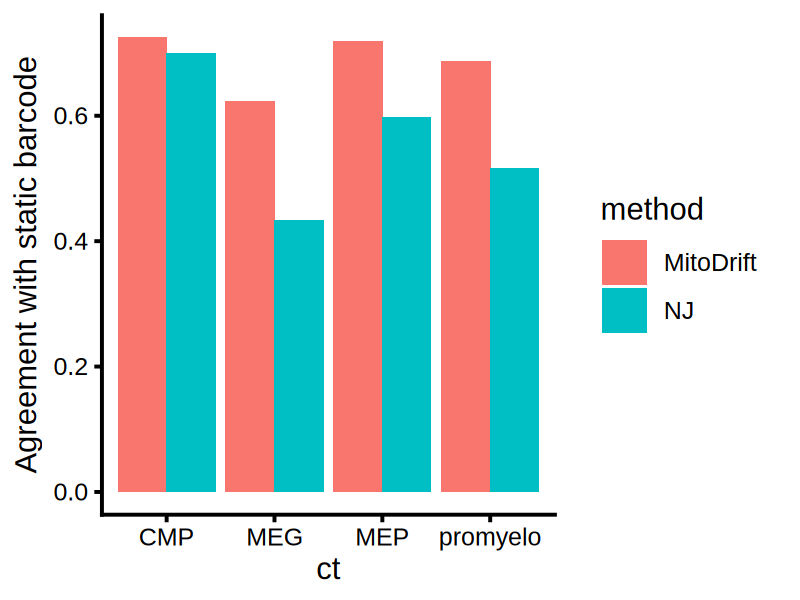

In [15]:
options(repr.plot.width = 4, repr.plot.height = 3, repr.plot.res = 200)

test_res_all %>% filter(method != 'barcode') %>% 
    left_join(
        test_res_all %>% filter(method == 'barcode') %>% select(ct, cmean_barcode = cmean, gene),
        by = join_by(gene, ct)
    ) %>%
    group_by(ct, method) %>%
    summarise(
        rho = cor(cmean, cmean_barcode),
        .groups = 'drop'
    ) %>%
    ggplot(
        aes(x = ct, y = rho, fill = method)
    ) +
    geom_col(position = position_dodge()) +
    theme_classic() +
    ylab('Agreement with static barcode')

# Visualize on tree

In [18]:
plot_one = function(ct, feature) {
    cells_select = seu@meta.data %>% filter(manual_label == ct) %>% rownames(.)
    phy_test = phy_trim %>% keep_tip_safe(cells_select) %>%
        drop_singletons() %>% 
        add_node_names()
    
    score_dict = tf_mat[feature,]
    # names(score_dict) = sample(names(score_dict))
    node_scores = compute_internal_node_scores(phy_test, score_dict, singletons = T, min_clade_size = 2)
    score_dict = node_scores %>% {setNames(.$z_adj, .$label)}
    score_dict_prop = propagate_scores_down_max(phy_test, score_dict, threshold = 0)
    node_scores = node_scores %>% mutate(z_adj_prop = score_dict_prop[label])
    
    p_tree = phy_test %>% 
        plot_phylo_circ(
            feature_mat = tf_mat[feature,phy_test$tip.label,drop=F],
            rescale = T,
            branch_width = 0.2,
            pwidth_annot = 0.1,
            # legend = T,
            layered = T,
            limits = c(-2,2),
            feature_legend_title = 'Cell TF activity',
            feature_axis_label = F
        ) +
        theme(
            plot.title = element_text(hjust = 0.5),
            plot.margin = margin(0,0,0,0)
        ) +
        ggtitle('') +
        theme(
            legend.position = 'top',
            # legend.justification = 0.5,
            legend.direction = 'horizontal',
            legend.title.position = 'top',
            legend.box = "vertical",
            legend.background = element_rect(fill = 'transparent', colour = NA),
            legend.key.height = unit(3, 'mm'),
            legend.key.width = unit(4, 'mm'),
            legend.title = element_text(hjust = 0.5, size = 11, margin = margin(0,0,b = 1,0, 'pt')),
            legend.box.margin = margin(t = 0, 0, 0, 0, 'pt'),
    		legend.margin = margin(t = 0, 0, 0, 0,  'pt'),
    		legend.spacing = unit(0, "pt"),
    		legend.spacing.y = unit(1, "pt"),
            legend.text = element_text(margin = margin(t = 1,'pt'))
        ) +
        theme_transparent
    
    p_tree %<+% node_scores +
        aes(color = z_adj_prop) +
        scale_color_gradient2(
            name = 'Clade TF activity',
            low = "blue", mid = 'gray80', high = "red",
            limits = c(-2,2), 
            oob = scales::oob_squish,
            na.value = 'gray80'
        )
}

In [144]:
R.utils::sourceDirectory(glue('../../R'))

In [19]:
options(repr.plot.width = 7, repr.plot.height = 5, repr.plot.res = 300)

tf_ct_dict = list(
    'CMP' = c('CEBPA', 'CEBPB', 'NR3C1', 'IRF8'),
    'MEP' = c('GATA2', 'RREB1', 'MYB', 'THRB')
)

for (ct in c('CMP', 'MEP')) {

    for (tf in tf_ct_dict[[ct]]) {
        p = plot_one(ct, tf) + theme(legend.position = 'none')
        ggsave(glue('outputs/{ct}_{tf}_rings.pdf'), p, width = 2.5, height = 2.5)
    }
}

options(repr.plot.width = 1.5, repr.plot.height = 1, repr.plot.res = 300)

leg = cowplot::get_legend(p + theme(legend.position = 'top'))
p_leg = ggpubr::as_ggplot(leg)
ggsave(glue('outputs/tf_ring_legend.pdf'), p_leg, width = 1.5, height = 1)

Warning message in fortify(data, ...):
“Arguments in `...` must be used.
✖ Problematic arguments:
• as.Date = as.Date
• yscale_mapping = yscale_mapping
• branch.length = branch.length
• hang = hang
• linewidth = branch_width
ℹ Did you misspell an argument name?”
Found more than one class "phylo" in cache; using the first, from namespace 'tidytree'

Also defined by ‘TreeTools’

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message in unit(c(t, r, b, l), unit):
“NAs introduced by coercion”
Warning message in fortify(data, ...):
“Arguments in `...` must be used.
✖ Problematic arguments:
• as.Date = as.Date
• yscale_mapping = yscale_mapping
• branch.length = branch.length
• hang = hang
• linewidth = branch_width
ℹ Did you misspell an argument name?”
Found more than one class "phylo" in cache; using the first, from namespace 'tidytree'

Also defined by ‘TreeTools’

Scale for y is already present.
Adding another scale for y, which 